# Final roof model: all 24 labels, crop augmentation, CV-informed epoch budget

Upload the supplied `final_training.py` into the **same runtime `roof_utils/` folder** as your other modules. Keep the current `cross_validation.py` with threshold support. Select your Colab GPU kernel and restart it after updating modules. No Google Drive setup is required. Run the cells below in order.

This refits a fresh ImageNet-initialized model on all 24 usable labelled images; image 278 stays excluded. It does not reuse one fold's trained weights. We are skipping the additional-seed experiment as requested.

**There is no held-out validation set in this final fit.** The median best epoch from your five completed crop folds becomes the fixed training budget (or use the explicit override below). `monitor="val_loss"`, `min_epochs=30`, and `patience=20` are retained in the shared configuration for reference but are inactive here. No `best.pt` is selected; `final.pt` is the model at the selected final epoch. Training loss is not an independent accuracy estimate. More epochs are not guaranteed to improve generalization.

Threshold 0.45 and crop augmentation were selected using development results. Predictions on the five unlabelled images have no ground truth for scoring. Your previous cross-validation reports remain the performance evidence.


In [12]:
# Run this before importing project modules. Preserve Colab's working CUDA stack.
import sys, subprocess, importlib.util
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy>=1.24,<3', 'Pillow>=10,<13', 'matplotlib>=3.8,<4'])
if any(importlib.util.find_spec(name) is None for name in ('torch', 'torchvision')):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch==2.8.0', 'torchvision==0.23.0'])
# If pip requests a kernel restart, restart and rerun from here.


In [13]:
from pathlib import Path
import os
import sys
import importlib
import shutil

# Set this only if automatic discovery finds no project or multiple projects.
PROJECT_ROOT_OVERRIDE = os.environ.get('DIDA_PROJECT_ROOT', '')
if PROJECT_ROOT_OVERRIDE:
    candidates = [Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()]
else:
    candidates = [Path.cwd(), *Path.cwd().parents]
    if Path('/content').is_dir():
        candidates += [p.parent for p in Path('/content').rglob('pyproject.toml')]
roots = sorted({p.resolve() for p in candidates
                if (p / 'pyproject.toml').is_file() and (p / 'roof_utils').is_dir()})
if len(roots) != 1:
    raise RuntimeError(
        f'Found project roots: {roots}. Set PROJECT_ROOT_OVERRIDE to the runtime '
        'project directory. If none exist, upload the project/data to this Colab server.')
PROJECT_ROOT = roots[0]

# A file uploaded separately through VS Code may land at /content instead.
module_file = PROJECT_ROOT / 'roof_utils' / 'final_training.py'
uploaded = Path('/content/final_training.py')
if not module_file.is_file() and uploaded.is_file():
    if 'def train_final_model(' not in uploaded.read_text():
        raise ValueError('Uploaded final_training.py does not contain the expected utility.')
    shutil.copy2(uploaded, module_file)
if not module_file.is_file():
    raise FileNotFoundError(f'Upload final_training.py to {module_file}')

sys.path.insert(0, str(PROJECT_ROOT))
importlib.invalidate_caches()
import roof_utils
if Path(roof_utils.__file__).resolve().parent != PROJECT_ROOT / 'roof_utils':
    raise RuntimeError('A different roof_utils is cached. Restart the kernel and rerun in order.')
from roof_utils.config import load_paths

env_file = PROJECT_ROOT / '.env'
if not env_file.exists():
    env_file.write_text(
        'RAW_DATA_DIR=data\nPREPARED_DATA_DIR=data_preparation_outputs\n'
        'MODELS_DIR=models\nREPORTS_DIR=reports\n')
paths = load_paths(PROJECT_ROOT)
for directory in (paths.raw_data_dir, paths.prepared_data_dir):
    if not directory.is_dir():
        raise FileNotFoundError(f'{directory} is unavailable. Check runtime paths in {env_file}.')
print('Project:', PROJECT_ROOT)
print('Models:', paths.models_dir)
print('Reports:', paths.reports_dir)


Project: /content
Models: /content/models
Reports: /content/reports


In [14]:
import torch
from roof_utils.config import load_paths
from roof_utils.cross_validation import CVConfig
from roof_utils.final_training import (
    train_final_model, predict_unlabelled, show_final_results, export_final_run,
)
from roof_utils.validation_splits import print_split_summary
assert torch.cuda.is_available(), 'Select the Colab GPU kernel.'
print('GPU:', torch.cuda.get_device_name(0))
print_split_summary(paths)  # Validates the frozen eligible IDs and data hashes.


GPU: Tesla T4
Plan: v1 | Seed: 42
Scope: Fixed image-level development CV; geographic independence is NOT established. Not an independent final test.
Grouping: Singleton visual scene groups after inspection of 30 images and candidate-pair screening; no repeated building/scene confirmed. These IDs are not known geographic locations.
Excluded: {'278': 'quarantined', '535': 'unlabelled', '537': 'unlabelled', '539': 'unlabelled', '551': 'unlabelled', '553': 'unlabelled'}
Fold 0: train=20, validation=4, roof/valid=13.89%; IDs=121, 241, 328, 417
Fold 1: train=19, validation=5, roof/valid=16.76%; IDs=270, 301, 308, 314, 317
Fold 2: train=19, validation=5, roof/valid=15.31%; IDs=287, 320, 343, 345, 379
Fold 3: train=19, validation=5, roof/valid=15.56%; IDs=284, 300, 303, 315, 324
Fold 4: train=19, validation=5, roof/valid=13.56%; IDs=272, 274, 337, 381, 532
PASS: no split overlap; all 24 eligible images validate exactly once; groups intact; data hashes match.


In [15]:
import json
import numpy as np

CROP_RUN = "crop_lr_3x_500"  # Your completed crop experiment
# Leave as None to use the median best epoch across all five crop folds.
# Set an integer only when deliberately choosing a fixed budget instead.
FINAL_EPOCHS_OVERRIDE = None

if FINAL_EPOCHS_OVERRIDE is None:
    root = paths.reports_dir / CROP_RUN
    best_epochs = []
    for fold in range(5):
        result_file = root / f"fold_{fold}" / "result.json"
        if not result_file.is_file():
            raise FileNotFoundError(
                f'Missing {result_file}. Upload the completed crop reports to '
                'REPORTS_DIR, correct CROP_RUN, or explicitly set FINAL_EPOCHS_OVERRIDE.')
        record = json.loads(result_file.read_text())
        best_epochs.append(record['best_epoch'])
        print(f"Fold {fold}: best epoch {record['best_epoch']}; "
              f"completed {record['epochs_completed']}")
    final_epochs = int(np.median(best_epochs))
else:
    if not isinstance(FINAL_EPOCHS_OVERRIDE, int) or FINAL_EPOCHS_OVERRIDE < 1:
        raise ValueError('FINAL_EPOCHS_OVERRIDE must be a positive integer or None')
    final_epochs = FINAL_EPOCHS_OVERRIDE
print('Fixed final training budget:', final_epochs, 'epochs')


Fold 0: best epoch 173; completed 193
Fold 1: best epoch 138; completed 158
Fold 2: best epoch 207; completed 227
Fold 3: best epoch 196; completed 216
Fold 4: best epoch 304; completed 324
Fixed final training budget: 196 epochs


In [16]:
RUN_NAME = f"final_crop_lr3x_t045_{final_epochs}epochs"

CONFIG = CVConfig(
    crop_probability=0.3,
    threshold=0.45,
    encoder_lr=3e-5,
    decoder_lr=3e-4,
    warmup_decoder_lr=1e-3,  # Unchanged from the candidate experiment
    warmup_epochs=5,
    monitor="val_loss",      # Inactive: final fit has no validation set
    min_epochs=min(30, final_epochs),  # Inactive
    patience=20,            # Inactive
    max_epochs=final_epochs,
)

print(CONFIG)
print(
    "Final fit uses all labels and trains for exactly",
    CONFIG.max_epochs,
    "epochs.",
)

CVConfig(seed=42, max_epochs=196, warmup_epochs=5, patience=20, monitor='val_loss', min_epochs=30, threshold=0.45, batch_size=4, crop_probability=0.3, encoder_lr=3e-05, warmup_decoder_lr=0.001, decoder_lr=0.0003, weight_decay=0.0001)
Final fit uses all labels and trains for exactly 196 epochs.


## Train the final model


In [17]:
result = train_final_model(paths, RUN_NAME, CONFIG, device="cuda")
result

Final refit: 24 labels; 196 epochs; no validation early stopping.
epoch   1/196 | augmented training loss 0.6723
epoch   2/196 | augmented training loss 0.5702
epoch   3/196 | augmented training loss 0.5178
epoch   4/196 | augmented training loss 0.4899
epoch   5/196 | augmented training loss 0.4715
epoch   6/196 | augmented training loss 0.4504
epoch   7/196 | augmented training loss 0.4436
epoch   8/196 | augmented training loss 0.4412
epoch   9/196 | augmented training loss 0.4299
epoch  10/196 | augmented training loss 0.4193
epoch  11/196 | augmented training loss 0.4167
epoch  12/196 | augmented training loss 0.4092
epoch  13/196 | augmented training loss 0.3987
epoch  14/196 | augmented training loss 0.3935
epoch  15/196 | augmented training loss 0.3891
epoch  16/196 | augmented training loss 0.3854
epoch  17/196 | augmented training loss 0.3798
epoch  18/196 | augmented training loss 0.3722
epoch  19/196 | augmented training loss 0.3663
epoch  20/196 | augmented training loss 0

{'run_name': 'final_crop_lr3x_t045_196epochs',
 'epochs_completed': 196,
 'train_ids': ['121',
  '241',
  '270',
  '272',
  '274',
  '284',
  '287',
  '300',
  '301',
  '303',
  '308',
  '314',
  '315',
  '317',
  '320',
  '324',
  '328',
  '337',
  '343',
  '345',
  '379',
  '381',
  '417',
  '532'],
 'threshold': 0.45,
 'device': 'cuda',
 'checkpoint': '/content/models/final_crop_lr3x_t045_196epochs/final.pt',
 'scope': 'No held-out evaluation; training loss is not a generalization score.'}

## Predict the five unlabelled images

No augmentation is applied during inference. Exports include full-resolution probabilities (`.npz`), binary roof masks (`*_roof.png`, 0/255), validity masks (`*_valid.png`) and prediction metadata. Invalid pixels are zeroed and must be interpreted using the validity mask. Threshold comes from the final checkpoint.


In [18]:
predictions = predict_unlabelled(paths, RUN_NAME, device="cuda")
predictions

[{'id': '535',
  'threshold': 0.45,
  'predicted_roof_fraction': 0.2028906955736224},
 {'id': '537',
  'threshold': 0.45,
  'predicted_roof_fraction': 0.14958743678466863},
 {'id': '539',
  'threshold': 0.45,
  'predicted_roof_fraction': 0.12499114542749876},
 {'id': '551',
  'threshold': 0.45,
  'predicted_roof_fraction': 0.09487498058704767},
 {'id': '553',
  'threshold': 0.45,
  'predicted_roof_fraction': 0.13653314086370744}]

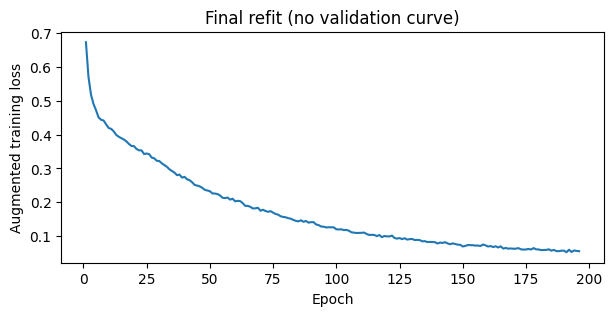

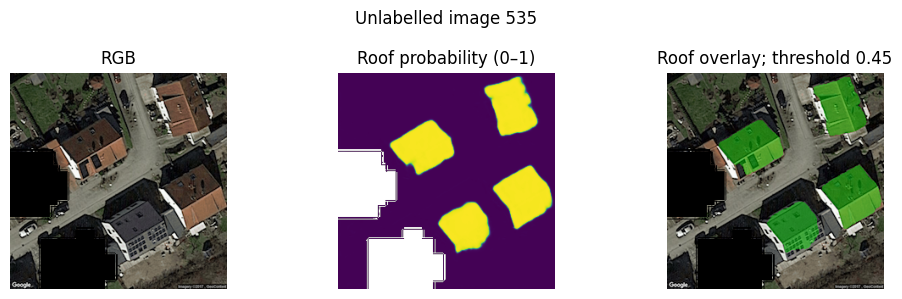

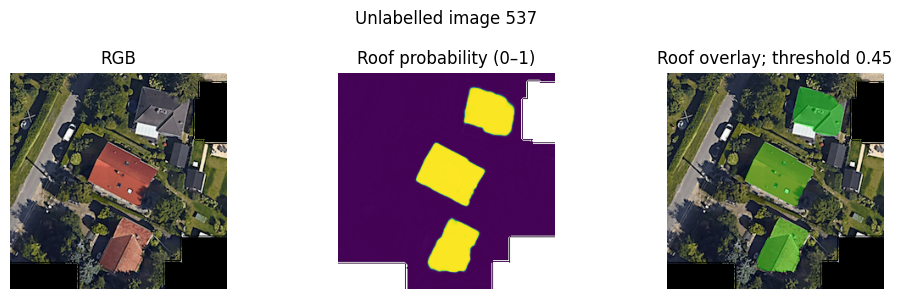

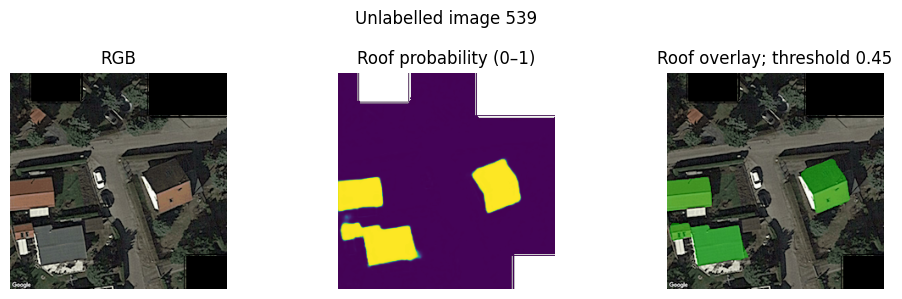

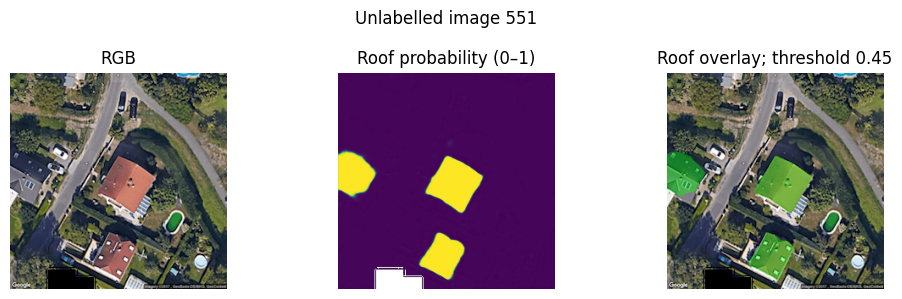

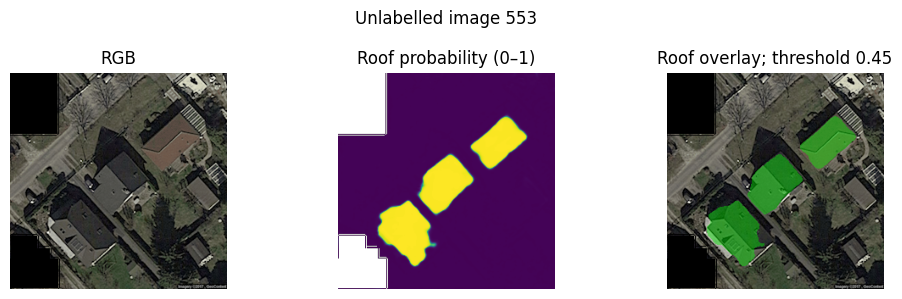

In [19]:
show_final_results(paths, RUN_NAME)

## Save the results locally

`MODELS_DIR/<run>/final.pt` is the inference model; `last.pt` contains optimizer/RNG state for resume. `REPORTS_DIR/<run>/` contains configuration, training history and unlabelled predictions.

The following cell creates one archive with model checkpoints, reports and utility code. **If these paths are on the Colab temporary disk, download the archive to your computer through the Colab file browser in VS Code before deleting the runtime. Creating the ZIP alone does not preserve it.** The raw/prepared dataset is not included in this export; retain your existing local copy.


In [20]:
archive = export_final_run(paths, RUN_NAME)
print(archive)

Download this archive before the runtime is deleted: /content/reports/final_crop_lr3x_t045_196epochs_export.zip
/content/reports/final_crop_lr3x_t045_196epochs_export.zip
